In [2]:
#  Load Libraries & Models
import shap, pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt

path = r'C:\my project\ipl-analytics-command-center\ml_models'
model_wp = pickle.load(open(f'{path}\\win_probability_model.pkl','rb'))
model_sp = pickle.load(open(f'{path}\\score_predictor_model.pkl','rb'))
model_pp = pickle.load(open(f'{path}\\player_performance_model.pkl','rb'))
model_av = pickle.load(open(f'{path}\\auction_value_model.pkl','rb'))

print(" All 4 Models Loaded!")

 All 4 Models Loaded!


In [3]:
#  Load & Prepare Data
matches    = pd.read_csv(r'C:\my project\ipl-analytics-command-center\data\matches_clean.csv')
deliveries = pd.read_csv(r'C:\my project\ipl-analytics-command-center\data\deliveries_clean.csv')

df = deliveries.merge(matches[['Id','Winner']], left_on='Match Id', right_on='Id').drop(columns='Id')
df = df[df['Inning']==1].sort_values(['Match Id','Over','Ball'])

g  = df.groupby('Match Id')
df[['Runs So Far','Wickets So Far']] = g[['Total Runs','Is Wicket']].cumsum()
df['Balls So Far'] = g.cumcount() + 1
df['Balls Left']   = 120 - df['Balls So Far']
df['CRR']          = df['Runs So Far'] / df['Balls So Far'] * 6

print(df.shape)

(135018, 26)


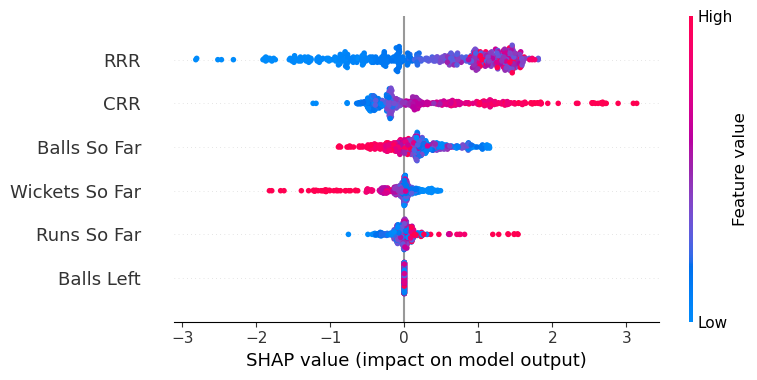

In [12]:
# SHAP — Win Probability Model
if 'Total Score' in df.columns: df.drop(columns='Total Score', inplace=True)

target = df.groupby('Match Id')['Total Runs'].sum().reset_index(name='Total Score')
df     = df.merge(target, on='Match Id')
df['RRR'] = (df['Total Score'] + 1 - df['Runs So Far']) / (df['Balls Left'] / 6).replace(0, 1)

features = ['Runs So Far','Balls So Far','Wickets So Far','Balls Left','CRR','RRR']
X = df[features].replace([np.inf,-np.inf],0).fillna(0)

explainer_wp = shap.TreeExplainer(model_wp)
shap_wp      = explainer_wp.shap_values(X[:500])

shap.summary_plot(shap_wp, X[:500], feature_names=features)

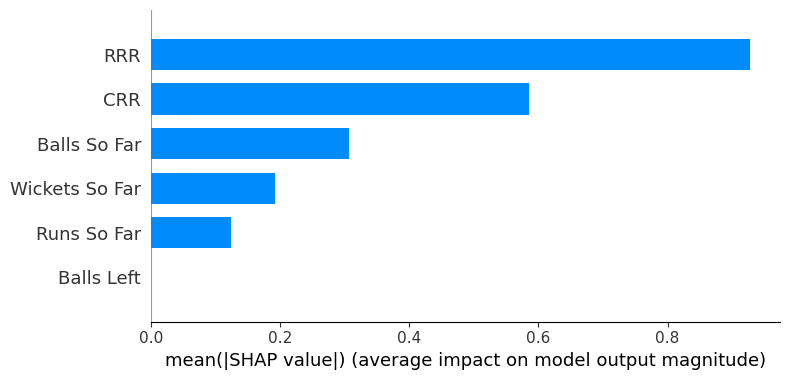

In [13]:
#  SHAP — Win Probability Bar Plot
shap.summary_plot(shap_wp, X[:500], feature_names=features, plot_type='bar')

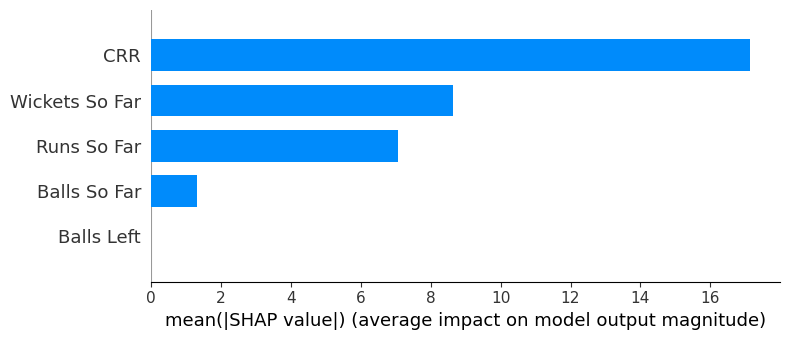

In [14]:
#  SHAP — Score Predictor Model
features_sp = ['Runs So Far','Balls So Far','Wickets So Far','Balls Left','CRR']
X2 = df[features_sp].replace([np.inf,-np.inf],0).fillna(0)

explainer_sp = shap.TreeExplainer(model_sp)
shap_sp      = explainer_sp.shap_values(X2[:500])

shap.summary_plot(shap_sp, X2[:500], feature_names=features_sp, plot_type='bar')

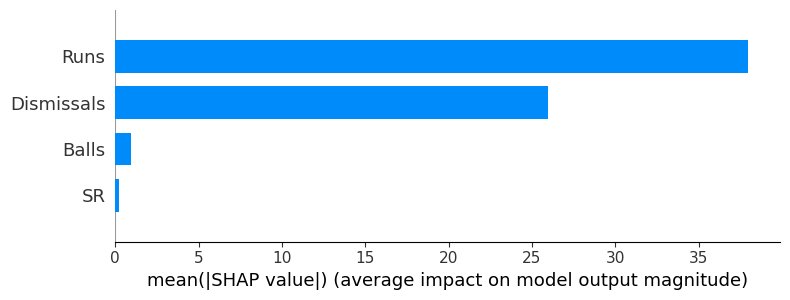

In [15]:
#  SHAP — Player Performance Model
features_pp = ['Runs','Balls','Dismissals','SR']
X3 = pd.DataFrame({'Runs': df['Runs So Far'], 'Balls': df['Balls So Far'],
                   'Dismissals': df['Is Wicket'], 'SR': df['CRR']*100/6}).fillna(0)

explainer_pp = shap.TreeExplainer(model_pp)
shap_pp      = explainer_pp.shap_values(X3[:500])

shap.summary_plot(shap_pp, X3[:500], feature_names=features_pp, plot_type='bar')

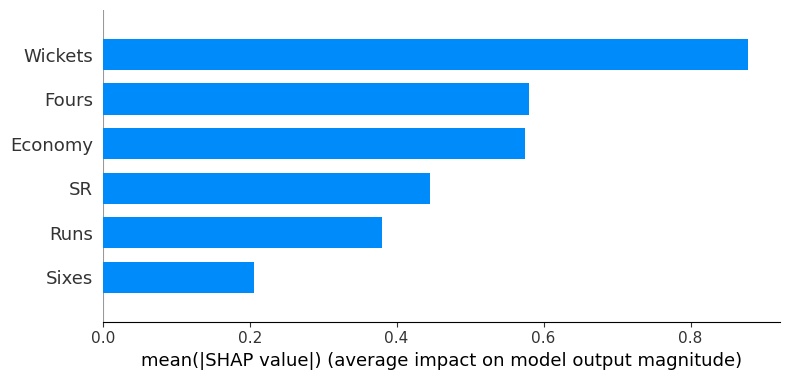

In [17]:
#  SHAP — Auction Value Model
from sklearn.preprocessing import LabelEncoder

bat = deliveries.groupby('Batter').agg(
    Runs=('Batsman Runs','sum'), SR=('Batsman Runs','count'),
    Fours=('Is Four','sum'), Sixes=('Is Six','sum')
).eval('SR = Runs/SR*100').reset_index()

bowl = deliveries.groupby('Bowler').agg(
    Wickets=('Is Wicket','sum'), Runs_Given=('Total Runs','sum'), Balls=('Total Runs','count')
).eval('Economy = Runs_Given/Balls*6').reset_index()

auction = bat.merge(bowl, left_on='Batter', right_on='Bowler', how='outer').fillna(0)
auction.columns = auction.columns.str.replace('_x','_bat').str.replace('_y','_bowl')

X4 = auction[['Runs','SR','Fours','Sixes','Wickets','Economy']].fillna(0)
explainer_av = shap.TreeExplainer(model_av)
shap_av      = explainer_av.shap_values(X4)

shap.summary_plot(shap_av, X4, feature_names=['Runs','SR','Fours','Sixes','Wickets','Economy'], plot_type='bar')

 All 12 SHAP plots saved!


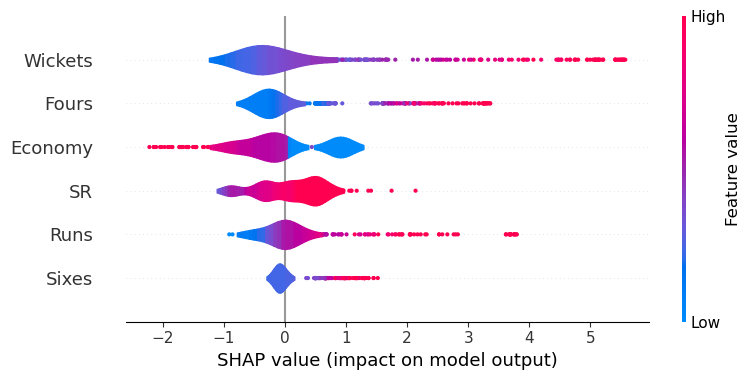

In [21]:
#  Save All SHAP Plots
path = r'C:\my project\ipl-analytics-command-center\shap_plots'
os.makedirs(path, exist_ok=True)

plots  = [('win_probability',shap_wp,X[:500],features),('score_predictor',shap_sp,X2[:500],features_sp),('player_performance',shap_pp,X3[:500],features_pp),('auction_value',shap_av,X4,['Runs','SR','Fours','Sixes','Wickets','Economy'])]
ptypes = ['dot','bar','violin']

[plt.close() or shap.summary_plot(v,d,feature_names=f,plot_type=p,show=False) or plt.savefig(f'{path}\\{n}_{p}.png',bbox_inches='tight',dpi=150) for n,v,d,f in plots for p in ptypes]

print(" All 12 SHAP plots saved!")